<a href="https://colab.research.google.com/github/Artomic2020/Break_the_Universe/blob/main/IDATG2208_1_Superconductor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



**Machine Learning — IDATG2208**  **bold text**
**NTNU Gjøvik**

**Student:** Art Olson  
**Date:** September 2026

## Assignment 1

Superconductivity — Regression Analysis

This assignment  regression methods for predicting the critical temperature (`critical_temp`) of superconducting materials. The analysis includes data exploration, feature correlation, single and multiple linear regression, cross-validation, regularization with Ridge and Lasso regression, and polynomial regression.

**Q1**.1.1 Examine the summary statistics (mean, standard deviation, min, max, quartiles) of all 81 features and the target. Which features show the highest variation? Justify why comparing raw standard deviations across these features can be misleading,and propose a more suitable measure.

In [32]:
from pathlib import Path
import pandas as pd
import zipfile
import urllib.request

def load_superconductivity_data():
    # Define the target directory
    target_dir = Path("idatg2208/Assignment1")
    target_dir.mkdir(parents=True, exist_ok=True)

    # Define the path for the zip file
    zip_file_name = "superconductivty+data.zip"
    zip_file_path = target_dir / zip_file_name

    # Define the URL for the zip file
    url = "https://archive.ics.uci.edu/static/public/464/superconductivty+data.zip"

    # Download the zip file if it doesn't exist
    if not zip_file_path.is_file():
        print(f"Downloading {zip_file_name}...")
        urllib.request.urlretrieve(url, zip_file_path)
        print(f"Downloaded to {zip_file_path}")

    # Extract the zip file
    extracted_path = target_dir
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        print(f"Extracting {zip_file_name} to {extracted_path}...")
        zip_ref.extractall(extracted_path)
        print("Extraction complete.")

    # Read train.csv from the extracted location
    train_csv_path = extracted_path / "train.csv"
    if not train_csv_path.is_file():
        print(f"Warning: train.csv not found directly in {extracted_path}. Please check zip file contents.")

    return pd.read_csv(train_csv_path)

superconductivity_df = load_superconductivity_data()
print("First 5 rows of the Superconductivity dataset:")
display(superconductivity_df.head())

Extracting superconductivty+data.zip to idatg2208/Assignment1...
Extraction complete.
First 5 rows of the Superconductivity dataset:


,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.0


In [33]:
#Q1.1.1 Examine the summary statistics (mean, standard deviation, min, max, quartiles) of
#all 81 features and the target. Which features show the highest variation? Justify
#why comparing raw standard deviations across these features can be misleading,
#and propose a more suitable measure.

In [34]:
print("Numerical summary statistics:")
display(superconductivity_df.describe())

Numerical summary statistics:


,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
count,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,...,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000
mean,4.115224,87.557631,72.988310,71.290627,58.539916,1.165608,1.063884,115.601251,33.225218,44.391893,...,3.153127,3.056536,3.055885,1.295682,1.052841,2.041010,1.483007,0.839342,0.673987,34.421219
std,1.439295,29.676497,33.490406,31.030272,36.651067,0.364930,0.401423,54.626887,26.967752,20.035430,...,1.191249,1.046257,1.174815,0.393155,0.380291,1.242345,0.978176,0.484676,0.455580,34.254362
min,1.000000,6.941000,6.423452,5.320573,1.960849,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000210
25%,3.000000,72.458076,52.143839,58.041225,35.248990,0.966676,0.775363,78.512902,16.824174,32.890369,...,2.116732,2.279705,2.091251,1.060857,0.775678,1.000000,0.921454,0.451754,0.306892,5.365000
50%,4.000000,84.922750,60.696571,66.361592,39.918385,1.199541,1.146783,122.906070,26.636008,45.123500,...,2.618182,2.615321,2.434057,1.368922,1.166532,2.000000,1.063077,0.800000,0.500000,20.000000
75%,5.000000,100.404410,86.103540,78.116681,73.113234,1.444537,1.359418,154.119320,38.356908,59.322812,...,4.026201,3.727919,3.914868,1.589027,1.330801,3.000000,1.918400,1.200000,1.020436,63.000000
max,9.000000,208.980400,208.980400,208.980400,208.980400,1.983797,1.958203,207.972460,205.589910,101.019700,...,7.000000,7.000000,7.000000,2.141963,1.949739,6.000000,6.992200,3.000000,3.000000,185.000000


**A. Which features show the highest variation?**
range_atomic_mass (54.62) std      mean 115 112 50%
wtd_gmean_atomic_mass (36.65) std  mean 58  50% 39
wtd_mean_atomic_mass (33.49) std   mean 72  50% 60.6

the differences in values at mean and 50% may suggest a skew or outliers
raw standard deviation (std) can be misleading because it can be skewed by extreme outliers (deviations are squrared, potentially providing outliers disproportionate influence)
standardization is a remedy

In [35]:
# Which features show the highest variation?
# range_atomic_mass (54.62) std      mean 115 112 50%
# wtd_gmean_atomic_mass (36.65) std  mean 58  50% 39
# wtd_mean_atomic_mass (33.49) std   mean 72  50% 60.6

# the differences in values at mean and 50% may suggest a skew or outliers
# raw standard deviation (std) can be misleading because it can be skewed by extreme outliers (deviations are squrared, potentially providing outliers disproportionate influence)
# standardization is a remedy


In [36]:
print("Info:")
display(superconductivity_df.info())

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21263 entries, 0 to 21262
Data columns (total 82 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   number_of_elements               21263 non-null  int64  
 1   mean_atomic_mass                 21263 non-null  float64
 2   wtd_mean_atomic_mass             21263 non-null  float64
 3   gmean_atomic_mass                21263 non-null  float64
 4   wtd_gmean_atomic_mass            21263 non-null  float64
 5   entropy_atomic_mass              21263 non-null  float64
 6   wtd_entropy_atomic_mass          21263 non-null  float64
 7   range_atomic_mass                21263 non-null  float64
 8   wtd_range_atomic_mass            21263 non-null  float64
 9   std_atomic_mass                  21263 non-null  float64
 10  wtd_std_atomic_mass              21263 non-null  float64
 11  mean_fie                         21263 non-null  float64
 12  wtd_mean_fie

None

In [37]:
print("Numerical summary statistics:value_counts")
display(superconductivity_df.value_counts())

Numerical summary statistics:value_counts


number_of_elements  mean_atomic_mass  wtd_mean_atomic_mass  gmean_atomic_mass  wtd_gmean_atomic_mass  entropy_atomic_mass  wtd_entropy_atomic_mass  range_atomic_mass  wtd_range_atomic_mass  std_atomic_mass  wtd_std_atomic_mass  mean_fie    wtd_mean_fie  gmean_fie   wtd_gmean_fie  entropy_fie  wtd_entropy_fie  range_fie  wtd_range_fie  std_fie     wtd_std_fie  mean_atomic_radius  wtd_mean_atomic_radius  gmean_atomic_radius  wtd_gmean_atomic_radius  entropy_atomic_radius  wtd_entropy_atomic_radius  range_atomic_radius  wtd_range_atomic_radius  std_atomic_radius  wtd_std_atomic_radius  mean_Density  wtd_mean_Density  gmean_Density  wtd_gmean_Density  entropy_Density  wtd_entropy_Density  range_Density  wtd_range_Density  std_Density  wtd_std_Density  mean_ElectronAffinity  wtd_mean_ElectronAffinity  gmean_ElectronAffinity  wtd_gmean_ElectronAffinity  entropy_ElectronAffinity  wtd_entropy_ElectronAffinity  range_ElectronAffinity  wtd_range_ElectronAffinity  std_ElectronAffinity  wtd_std_ElectronAffinity  mean_FusionHeat  wtd_mean_FusionHeat  gmean_FusionHeat  wtd_gmean_FusionHeat  entropy_FusionHeat  wtd_entropy_FusionHeat  range_FusionHeat  wtd_range_FusionHeat  std_FusionHeat  wtd_std_FusionHeat  mean_ThermalConductivity  wtd_mean_ThermalConductivity  gmean_ThermalConductivity  wtd_gmean_ThermalConductivity  entropy_ThermalConductivity  wtd_entropy_ThermalConductivity  range_ThermalConductivity  wtd_range_ThermalConductivity  std_ThermalConductivity  wtd_std_ThermalConductivity  mean_Valence  wtd_mean_Valence  gmean_Valence  wtd_gmean_Valence  entropy_Valence  wtd_entropy_Valence  range_Valence  wtd_range_Valence  std_Valence  wtd_std_Valence  critical_temp
2                   60.332250         55.636875             59.596931          55.099520              0.680984             0.621712                 18.781500          20.775375              9.390750         8.132628             614.400000  632.250000    613.361940  631.463853     0.691458     0.537853         71.4       342.900000     35.700000   30.917107    153.500000          162.250000              152.499180           161.484859               0.686634               0.513364                   35                   94.250000                17.500000          15.155445              6007.000000   6058.500000       6006.116882    6057.835764        0.693000         0.555222             206.0          3106.500000        103.000000   89.200617        41.250000              46.675000                  39.797487               45.535141                   0.658144                  0.444330                      21.7                    31.475000                   10.850000             9.396376                  14.195000        18.497500            11.289464         16.043684             0.496075            0.267766                17.21             15.702500             8.605000        7.452149            30.000000                 30.500000                     29.983329                  30.487427                      0.692592                     0.548420                         2.0                        16.000000                      1.000000                 0.866025                     4.000000      4.500000          3.872983       4.400559           0.661563         0.450561             2              3.000000           1.000000     0.866025         15.30            3
3                   50.619350         41.846910             37.889900          26.578972              0.880507             0.643754                 76.895150          30.580047              31.393140        36.656986            783.733333  895.157143    757.325358  863.075088     1.063095     0.689828         470.3      616.022449     213.992092  229.540353   150.000000          124.510204              134.421558           106.280406               1.005836               0.819425                   145                  70.897959                61.030047          69.695877              4280.666667   3229.714286       3952.

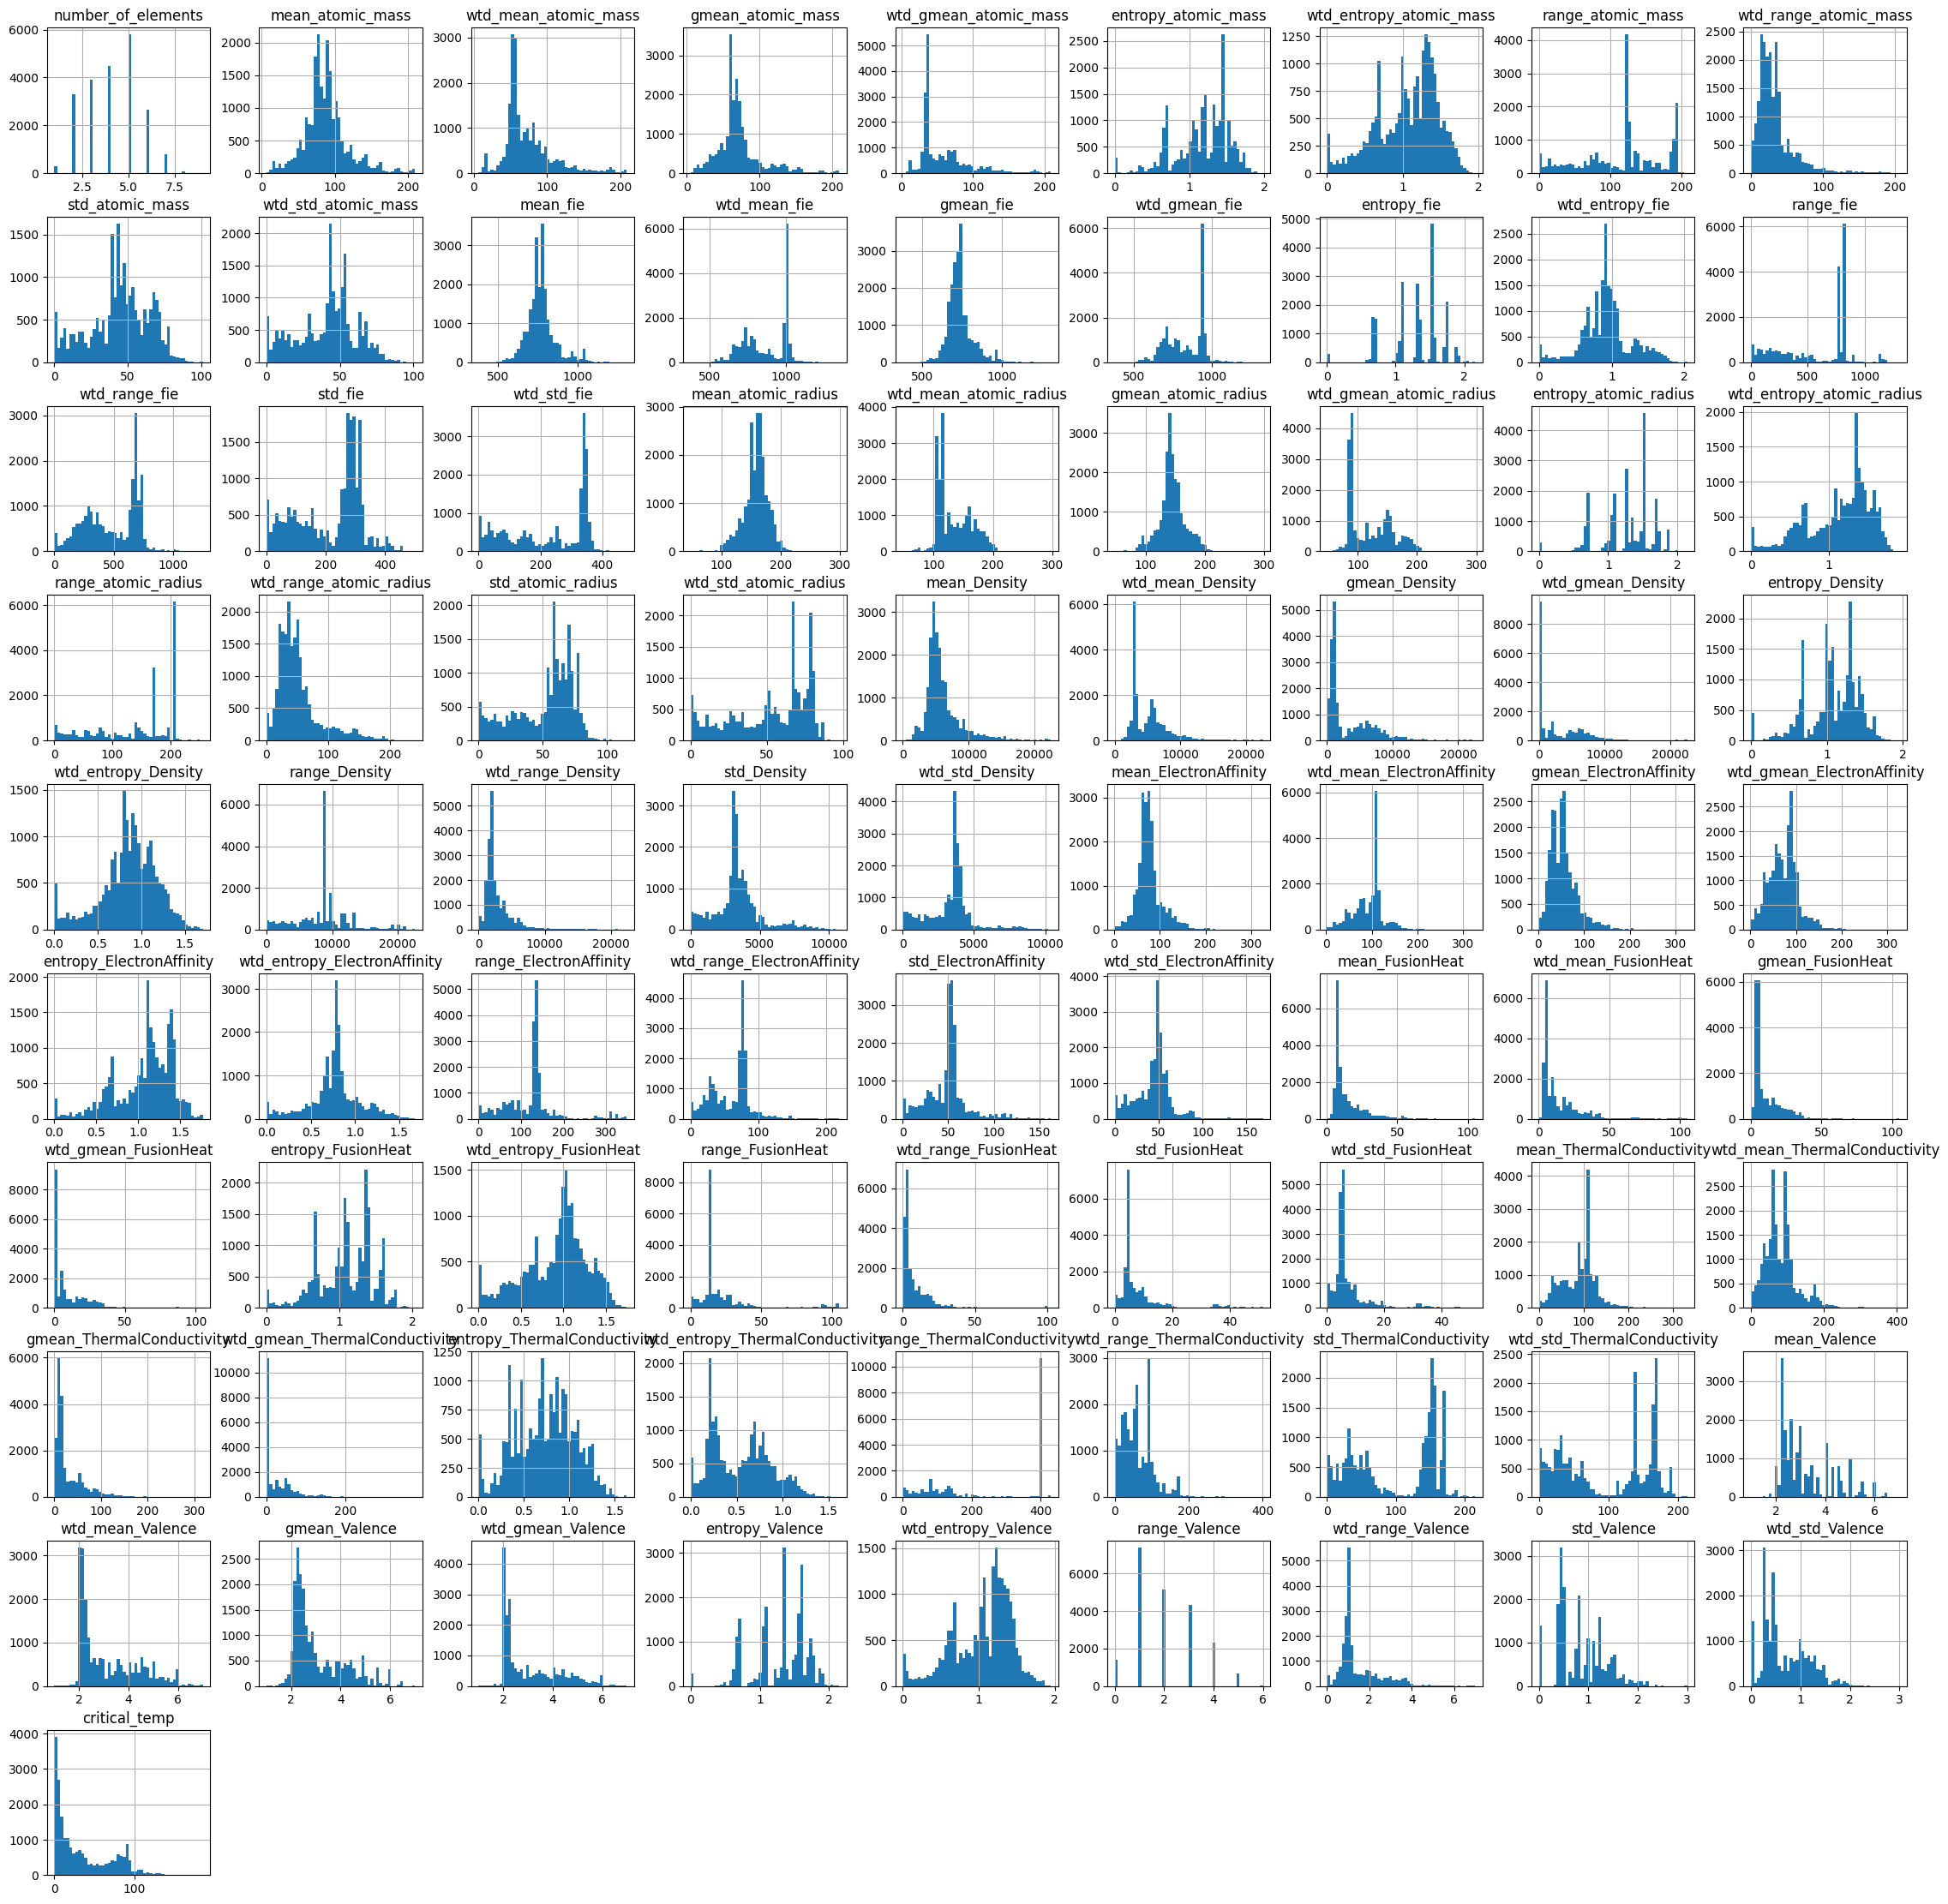

In [38]:
import matplotlib.pyplot as plt
superconductivity_df.hist(bins=50, figsize=(28,28))
plt.show()

**Q1.1.2** Plot the distribution of critical_temp before and after a log transform. Based on the shape of the distributions, discuss whether the raw or the transformed target should be used for regression later in this assignment.

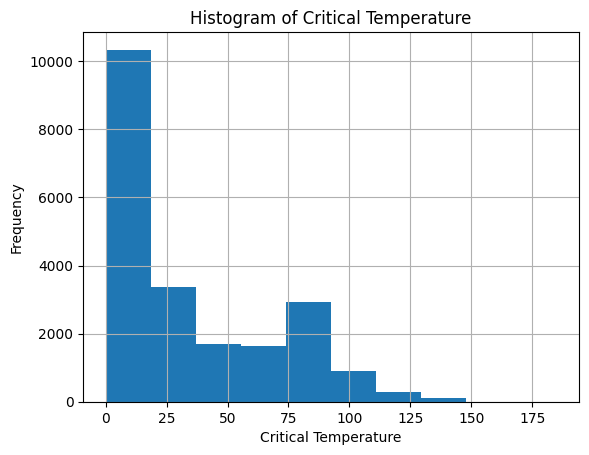

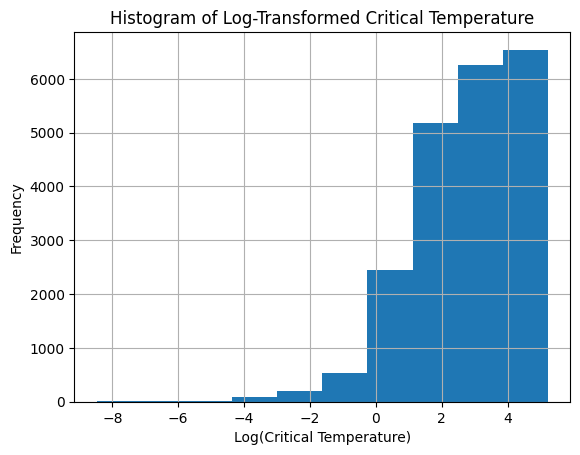

In [39]:
#Q1.1.2 Plot the distribution of critical_temp before and after a log transform. Based on
#the shape of the distributions, discuss whether the raw or the transformed target
#should be used for regression later in this assignment.

import numpy as np
import matplotlib.pyplot as plt

# Filter out critical_temp values that are not positive before applying log transformation
positive_critical_temp = superconductivity_df[superconductivity_df["critical_temp"] > 0]["critical_temp"]
positive_critical_temp.hist()
plt.title('Histogram of Critical Temperature')
plt.xlabel('Critical Temperature')
plt.ylabel('Frequency')
plt.show()
# Apply log transformation to the filtered values
log_critical_temp = np.log(positive_critical_temp)

# Plot the histogram of the log-transformed critical_temp
log_critical_temp.hist()
plt.title('Histogram of Log-Transformed Critical Temperature')
plt.xlabel('Log(Critical Temperature)')
plt.ylabel('Frequency')
plt.show()

Features sorted by their correlation with 'critical_temp':


,critical_temp
critical_temp,1.000000
wtd_std_ThermalConductivity,0.721271
range_ThermalConductivity,0.687654
range_atomic_radius,0.653759
std_ThermalConductivity,0.653632
wtd_entropy_atomic_mass,0.626930
wtd_entropy_atomic_radius,0.603494
number_of_elements,0.601069
range_fie,0.600790
wtd_std_atomic_radius,0.599199


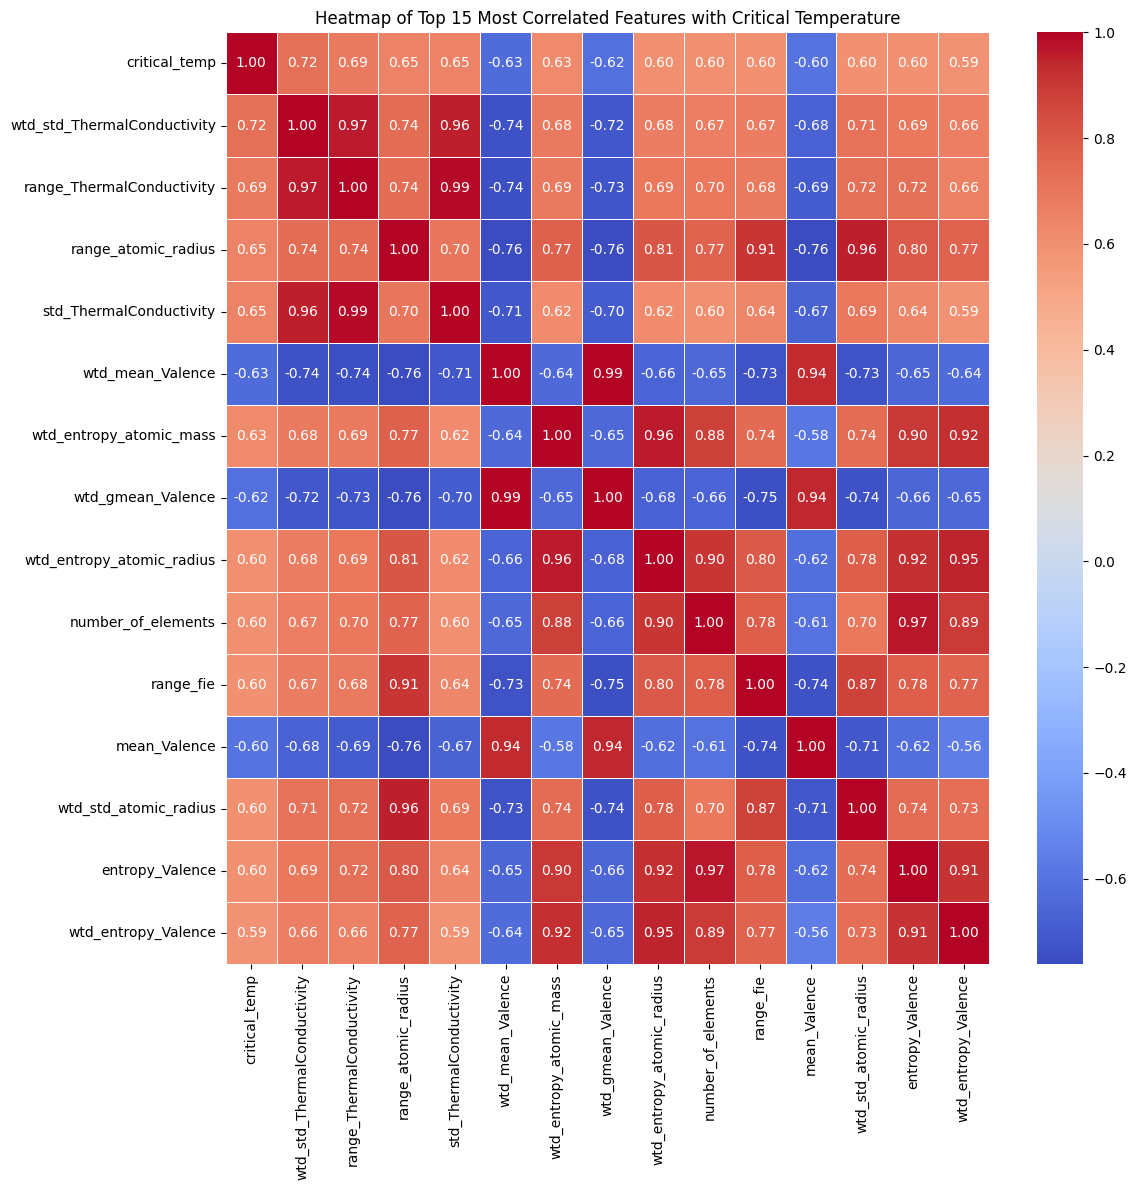


--- Highly Correlated Feature Pairs (absolute correlation > 0.9) ---
Pair 1: 'entropy_fie' and 'entropy_atomic_radius' (Correlation: 1.00)
Pair 2: 'wtd_mean_Valence' and 'wtd_gmean_Valence' (Correlation: 0.99)
Pair 3: 'entropy_fie' and 'entropy_Valence' (Correlation: 0.99)
Pair 4: 'wtd_mean_fie' and 'wtd_gmean_fie' (Correlation: 0.99)
Pair 5: 'mean_Valence' and 'gmean_Valence' (Correlation: 0.99)
Pair 6: 'entropy_atomic_radius' and 'entropy_Valence' (Correlation: 0.99)
Pair 7: 'range_ThermalConductivity' and 'std_ThermalConductivity' (Correlation: 0.99)
Pair 8: 'range_FusionHeat' and 'std_FusionHeat' (Correlation: 0.98)
Pair 9: 'range_fie' and 'std_fie' (Correlation: 0.98)
Pair 10: 'wtd_mean_atomic_radius' and 'wtd_gmean_atomic_radius' (Correlation: 0.98)


In [40]:
#Q1.2.1 Compute the correlation matrix of all features. Since a full 81 × 81 heatmap
#is unreadable, plot a heatmap restricted to the 15 features most correlated with
#critical_temp.


import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = superconductivity_df.corr(numeric_only=True)

# Get the names of the top 15 features by absolute correlation with 'critical_temp'
# This will include 'critical_temp' itself as the highest correlated feature.
top_15_features_names = corr_matrix["critical_temp"].abs().sort_values(ascending=False).head(15).index.tolist()

print("Features sorted by their correlation with 'critical_temp':")
display(corr_matrix["critical_temp"][top_15_features_names].sort_values(ascending=False))

# Create a sub-correlation matrix using only these top 15 features
top_corr_matrix = corr_matrix.loc[top_15_features_names, top_15_features_names]

# Plot the heatmap
plt.figure(figsize=(12, 12)) # Increased figure size for better visibility
sns.heatmap(top_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Heatmap of Top 15 Most Correlated Features with Critical Temperature')
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

print("\n--- Highly Correlated Feature Pairs (absolute correlation > 0.9) ---")
# Find highly correlated pairs (absolute correlation > 0.9)
highly_correlated_pairs = []
# Iterate through the upper triangle of the correlation matrix
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            highly_correlated_pairs.append(
                (corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j])
            )

# Sort by absolute correlation in descending order
highly_correlated_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

# Print the top 10 (or fewer if less than 5 exist)
for i, (feature1, feature2, correlation) in enumerate(highly_correlated_pairs[:10]):
    print(f"Pair {i+1}: '{feature1}' and '{feature2}' (Correlation: {correlation:.2f})")


**Q1.2.2** Which variable has the strongest positive correlation with critical_temp? Which variable has the strongest negative correlation?

**A.1.2.2** a/ wd_std_ThermalConductivity has the strongest positive correlation
b/ wtd_entropy_valence has the strongest negative correlation.

**Q1.2.3** Identify at least 5 pairs of features that are highly correlated with each other (absolute correlation above 0.9), independent of their relationship with the target

**A.1.2.3**

- Highly Correlated Feature Pairs (absolute correlation > 0.9) ---
Pair 1: 'entropy_fie' and 'entropy_atomic_radius' (Correlation: 1.00)
Pair 2: 'wtd_mean_Valence' and 'wtd_gmean_Valence' (Correlation: 0.99)
Pair 3: 'entropy_fie' and 'entropy_Valence' (Correlation: 0.99)
Pair 4: 'wtd_mean_fie' and 'wtd_gmean_fie' (Correlation: 0.99)
Pair 5: 'mean_Valence' and 'gmean_Valence' (Correlation: 0.99)

The 5 most highly correllated features are in fact measuring the same class of phenomena possibly in different ways,and they naturally have a high correllation. Perhaps more interesting are thepairs of variables that are highly
correllated AND measure different phenomena and representing different properties.

'entropy_fie' and 'entropy_atomic_radius''entropy_fie' and 'entropy_atomic_radius' (#1)
'entropy_atomic_radius' and 'entropy_Valence' (#6)

wtd_entropy_atomic_radius AND wd_entropy_Valence  (.95)
range_fie AND range_atomic_radius (.91)

**Q. 1.2.3** What problem does this create for a linear regression model, and how could it be addressed?

A. The overlapping categories might make trouble. Combining features that measure the same class of information would stabilize correlations. Multicolinearity in this collection of attributes makes it more difficult to attribute variations to one or another individual variable.
One way of addressing it is regularization.  Different measures of 'Valence' and 'fie" could be combined or regularized for more stabile correllations.

**Q1.2.4** Using your correlation analysis, select one feature you expect to be a strong predictor of critical_temp and one you expect to be a weak predictor. Justify your choice; you will use these two features in the next section.

In [42]:
critical_temp_correlations = corr_matrix['critical_temp']

# Get absolute correlations, dropping 'critical_temp' itself
abs_correlations = critical_temp_correlations.abs().drop('critical_temp')

# Find the top 5 strongest predictors
top_5_strongest_features = abs_correlations.nlargest(5).index.tolist()
top_5_strongest_correlations = critical_temp_correlations.loc[top_5_strongest_features]

# Find the bottom 5 weakest predictors
bottom_5_weakest_features = abs_correlations.nsmallest(5).index.tolist()
bottom_5_weakest_correlations = critical_temp_correlations.loc[bottom_5_weakest_features]

print("Top 5 Strongest Predictors of 'critical_temp':")
for feature, correlation in top_5_strongest_correlations.items():
    print(f"- '{feature}' (Correlation: {correlation:.2f})")

print("\nBottom 5 Weakest Predictors of 'critical_temp':")
for feature, correlation in bottom_5_weakest_correlations.items():
    print(f"- '{feature}' (Correlation: {correlation:.2f})")

Top 5 Strongest Predictors of 'critical_temp':
- 'wtd_std_ThermalConductivity' (Correlation: 0.72)
- 'range_ThermalConductivity' (Correlation: 0.69)
- 'range_atomic_radius' (Correlation: 0.65)
- 'std_ThermalConductivity' (Correlation: 0.65)
- 'wtd_mean_Valence' (Correlation: -0.63)

Bottom 5 Weakest Predictors of 'critical_temp':
- 'gmean_fie' (Correlation: -0.03)
- 'entropy_ThermalConductivity' (Correlation: 0.09)
- 'mean_fie' (Correlation: 0.10)
- 'mean_atomic_radius' (Correlation: 0.11)
- 'wtd_gmean_ElectronAffinity' (Correlation: -0.11)


Q 1.2.4 Using your correlation analysis, select one feature you expect to be a strong predictor of critical_temp and one you expect to be a weak predictor. Justify your choice; you will use these two features in the next section.

A. 1.2.4
*   Strongest Predictor of 'critical_temp'  among all features: 'wtd_std_ThermalConductivity'(Correlation: 0.72)
*   Weakest Predictor of 'critical_temp' among all features:
'gmean_fie' (Correlation: -0.03)

The correllation coeficcient ranges from -1 to 1. Strongly positive AND negative correlations are good predictors, while coefficients close to zero mean there is no linear correllation.




**1.3 Linear Regression**

Q1.3.1 Fit a simple linear regression model using gradient descent to predict critical_temp using only the weak predictor selected in Q1.2.4. Standardize the feature before running gradient descent and explain why this matters here.

A 1.3.1  Standardizationof features is critical for gradient descent because it helps ensure that all features contribute to the distance calculation in a way that prevents larger features from dominating the cost function. It also optimizes for speed.

In [43]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Select the weak predictor 'gmean_fie' and the target 'critical_temp'
X = superconductivity_df[['gmean_fie']].values
y = superconductivity_df['critical_temp'].values.reshape(-1, 1)

# Standardize the feature
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Shape of X_scaled:", X_scaled.shape)
print("Shape of y:", y.shape)

Shape of X_scaled: (21263, 1)
Shape of y: (21263, 1)


In [44]:
def gradient_descent_linear_regression(X, y, learning_rate=0.01, n_iterations=1000):
    # Initialize weights (theta0 for intercept, theta1 for feature)
    # We add a column of ones to X for the intercept term
    X_b = np.c_[np.ones((X.shape[0], 1)), X]

    # Initialize parameters (theta0 and theta1)
    theta = np.zeros((X_b.shape[1], 1))

    # Store cost history to observe convergence
    cost_history = []

    for iteration in range(n_iterations):
        # Calculate predictions
        predictions = X_b.dot(theta)

        # Calculate error
        errors = predictions - y

        # Calculate gradients
        gradients = (1/X_b.shape[0]) * X_b.T.dot(errors)

        # Update parameters
        theta = theta - learning_rate * gradients

        # Calculate and store the cost (Mean Squared Error)
        cost = (1/ (2 * X_b.shape[0])) * np.sum(np.square(errors))
        cost_history.append(cost)

        # Print progress occasionally
        if iteration % (n_iterations / 10) == 0:
            print(f"Iteration {iteration}: Cost = {cost:.4f}")

    return theta, cost_history


# Set hyperparameters
learning_rate = 0.05
n_iterations = 2000

# Run gradient descent
theta_gd, cost_history_gd = gradient_descent_linear_regression(X_scaled, y, learning_rate=learning_rate, n_iterations=n_iterations)

print("\nOptimized parameters (theta):")
print(f"Intercept (theta0): {theta_gd[0][0]:.4f}")
print(f"Coefficient for gmean_fie (theta1): {theta_gd[1][0]:.4f}")

Iteration 0: Cost = 1179.0632
Iteration 200: Cost = 586.2834
Iteration 400: Cost = 586.2834
Iteration 600: Cost = 586.2834
Iteration 800: Cost = 586.2834
Iteration 1000: Cost = 586.2834
Iteration 1200: Cost = 586.2834
Iteration 1400: Cost = 586.2834
Iteration 1600: Cost = 586.2834
Iteration 1800: Cost = 586.2834

Optimized parameters (theta):
Intercept (theta0): 34.4212
Coefficient for gmean_fie (theta1): -0.8599


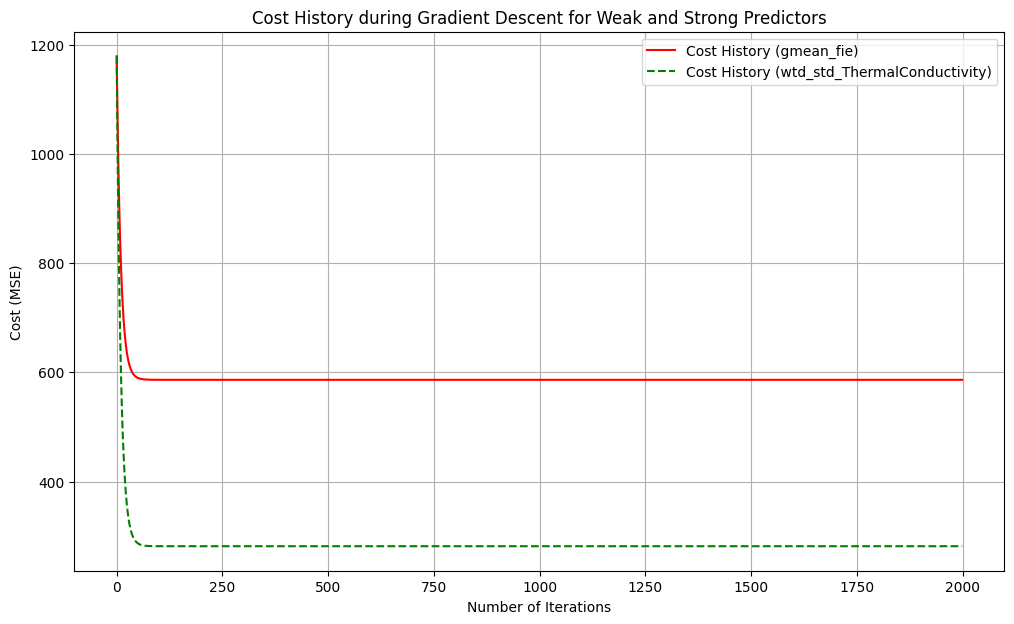

In [45]:
import matplotlib.pyplot as plt

# Plot the cost history for both predictors
plt.figure(figsize=(12, 7))
plt.plot(range(len(cost_history_gd)), cost_history_gd, label='Cost History (gmean_fie)', color='red')
plt.plot(range(len(cost_history_gd_strong)), cost_history_gd_strong, label='Cost History (wtd_std_ThermalConductivity)', color='green', linestyle='--')
plt.title('Cost History during Gradient Descent for Weak and Strong Predictors')
plt.xlabel('Number of Iterations')
plt.ylabel('Cost (MSE)')
plt.legend()
plt.grid(True)
plt.show()

In [46]:
X_strong = superconductivity_df[['wtd_std_ThermalConductivity']].values
X_strong_scaled = scaler.fit_transform(X_strong)

# Run gradient descent for the strong predictor
theta_gd_strong, cost_history_gd_strong = gradient_descent_linear_regression(
    X_strong_scaled, y, learning_rate=learning_rate, n_iterations=n_iterations
)

print("\nOptimized parameters for strong predictor (theta):")
print(f"Intercept (theta0): {theta_gd_strong[0][0]:.4f}")
print(f"Coefficient for wtd_std_ThermalConductivity (theta1): {theta_gd_strong[1][0]:.4f}")

Iteration 0: Cost = 1179.0632
Iteration 200: Cost = 281.4574
Iteration 400: Cost = 281.4574
Iteration 600: Cost = 281.4574
Iteration 800: Cost = 281.4574
Iteration 1000: Cost = 281.4574
Iteration 1200: Cost = 281.4574
Iteration 1400: Cost = 281.4574
Iteration 1600: Cost = 281.4574
Iteration 1800: Cost = 281.4574

Optimized parameters for strong predictor (theta):
Intercept (theta0): 34.4212
Coefficient for wtd_std_ThermalConductivity (theta1): 24.7061


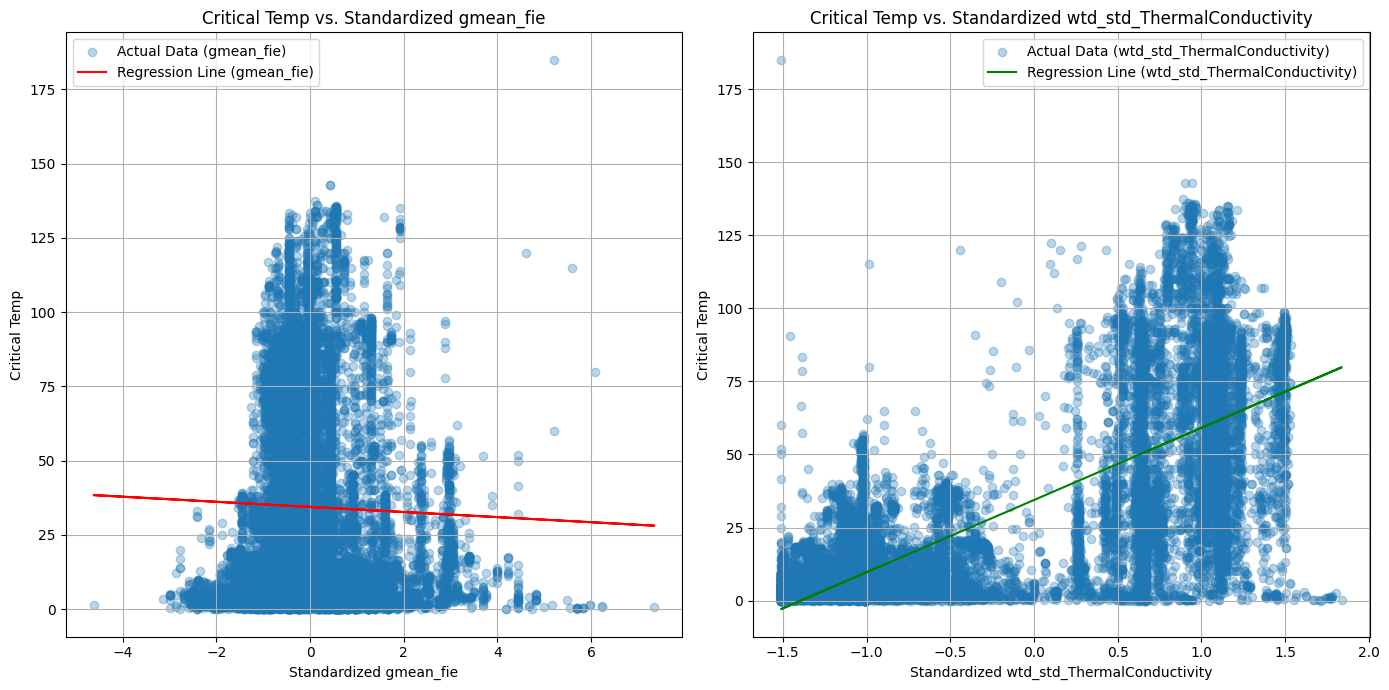

In [47]:
import matplotlib.pyplot as plt

# Generate predictions for the weak predictor
X_b_weak = np.c_[np.ones((X_scaled.shape[0], 1)), X_scaled]
predictions_weak = X_b_weak.dot(theta_gd)

# Generate predictions for the strong predictor
X_b_strong = np.c_[np.ones((X_strong_scaled.shape[0], 1)), X_strong_scaled]
predictions_strong = X_b_strong.dot(theta_gd_strong)

plt.figure(figsize=(14, 7))

# Plot for weak predictor: gmean_fie
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.scatter(X_scaled, y, alpha=0.3, label='Actual Data (gmean_fie)')
plt.plot(X_scaled, predictions_weak, color='red', label='Regression Line (gmean_fie)')
plt.title('Critical Temp vs. Standardized gmean_fie')
plt.xlabel('Standardized gmean_fie')
plt.ylabel('Critical Temp')
plt.legend()
plt.grid(True)

# Plot for strong predictor: wtd_std_ThermalConductivity
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.scatter(X_strong_scaled, y, alpha=0.3, label='Actual Data (wtd_std_ThermalConductivity)')
plt.plot(X_strong_scaled, predictions_strong, color='green', label='Regression Line (wtd_std_ThermalConductivity)')
plt.title('Critical Temp vs. Standardized wtd_std_ThermalConductivity')
plt.xlabel('Standardized wtd_std_ThermalConductivity')
plt.ylabel('Critical Temp')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**Q1.3.3** Report the regression coefficient and intercept and compare both models.

**Q1.3.4** Plot the regression line against the data points for both features. Does the regression line fit the data well in either case? Why or why not?

A1.3.3 & A1.3.4

**Regression Coefficients and Intercepts:**

*   **For `gmean_fie` (Weak Predictor):**
    *   Intercept (theta0): `34.4212`
    *   Coefficient for `gmean_fie` (theta1): `-0.8599`
    *   Model: `critical_temp = 34.4212 - 0.8599 * (standardized_gmean_fie)`
    *   Cost (MSE) at convergence: `586.2834`

*   **For `wtd_std_ThermalConductivity` (Strong Predictor):**
    *   Intercept (theta0): `34.4212`
    *   Coefficient for `wtd_std_ThermalConductivity` (theta1): `24.7061`
    *   Model: `critical_temp = 34.4212 + 24.7061 * (standardized_wtd_std_ThermalConductivity)`
    *   Cost (MSE) at convergence: `281.4574`

Comparison of Models:

Both models share a very similar intercept (`34.4212`), which represents the predicted `critical_temp` when the standardized feature is zero. However, their coefficients are vastly different:

*   The weak predictor (`gmean_fie`) has a small negative coefficient (`-0.8599`), indicating a very slight inverse relationship with `critical_temp`. A one-unit increase in standardized `gmean_fie` is associated with a `-0.8599` decrease in `critical_temp`.
*   The strong predictor (`wtd_std_ThermalConductivity`) has a much larger positive coefficient (`24.7061`), indicating a significant positive relationship. A one-unit increase in standardized `wtd_std_ThermalConductivity` is associated with a `24.7061` increase in `critical_temp`.

This difference in coefficients is reflected in their respective Mean Squared Error (MSE) values. The model using the strong predictor achieved a significantly lower MSE (`281.4574`) compared to the weak predictor's MSE (`586.2834`), indicating that it is a much better fit to the data and results in less prediction error.

Regression Line Fit to Data (referencing the plots):

*   `gmean_fie` (Weak Predictor - Left Plot):
    *   The regression line (red) is nearly horizontal, reflecting the very low correlation. The data points are widely scattered, and the line captures almost no discernible trend. This is because `gmean_fie` has a very low absolute correlation with `critical_temp`, meaning there's little linear relationship between them. The model explains very little of the variance in `critical_temp`.

*  `wtd_std_ThermalConductivity` (Strong Predictor - Right Plot):
    *   The regression line (green) has a clear upward slope, which aligns with the positive correlation. It **fits the data much better** than the weak predictor's line. While there's still considerable scatter (as it's a simple linear model), the line clearly follows the overall positive trend in the data points. The model is able to capture a significant portion of the linear relationship between this feature and `critical_temp`, as evidenced by its higher correlation coefficient and lower MSE.

**1.4 Train-Test Split**

Split the dataset into training (80%) and test (20%) sets in 5 different folds. Train the simple linear regression model (using gradient descent, with standardized features) for each split on the train-test data in each fold. Evaluate the model on the test set in each fold using:• Mean Squared Error (MSE)
• Root Mean Squared Error (RMSE)
• R2 score

In [64]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# Initialize KFold for 5 splits
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Prepare features (X) and target (y) for the full dataset
X_full = superconductivity_df.drop('critical_temp', axis=1)
y_full = superconductivity_df['critical_temp'].values.reshape(-1, 1)

# Store results for each predictor
mse_strong_scores = []
rmse_strong_scores = []
r2_strong_scores = []

mse_weak_scores = []
rmse_weak_scores = []
r2_weak_scores = []

# Store results for multiple linear regression
mse_multiple_scores = []
rmse_multiple_scores = []
r2_multiple_scores = []

# Store results for ridge regression
mse_ridge_scores = []
rmse_ridge_scores = []
r2_ridge_scores = []

# Store results for lasso regression

mse_lasso_scores = []
rmse_lasso_scores = []
r2_lasso_scores = []

# Store results for polynomial regression
mse_poly_scores = []
rmse_poly_scores = []
r2_poly_scores = []


# Store results for decision tree
mse_tree_scores = []
rmse_tree_scores = []
r2_tree_scores = []


# The gradient descent function
def gradient_descent_linear_regression(X, y, learning_rate=0.01, n_iterations=1000):
    X_b = np.c_[np.ones((X.shape[0], 1)), X]
    theta = np.zeros((X_b.shape[1], 1))
    cost_history = []

    for iteration in range(n_iterations):
        predictions = X_b.dot(theta)
        errors = predictions - y
        gradients = (1/X_b.shape[0]) * X_b.T.dot(errors)
        theta = theta - learning_rate * gradients
        cost = (1/ (2 * X_b.shape[0])) * np.sum(np.square(errors))
        cost_history.append(cost)
    return theta, cost_history

# Set hyperparameters for gradient descent
learning_rate = 0.05
n_iterations = 2000

print("Performing 5-Fold Cross-Validation...")

for fold, (train_index, test_index) in enumerate(kf.split(X_full)):
    print(f"\n--- Fold {fold+1}/5 ---")

    X_train_fold, X_test_fold = X_full.iloc[train_index], X_full.iloc[test_index]
    y_train_fold, y_test_fold = y_full[train_index], y_full[test_index]

    # --- Evaluate Strong Predictor: 'wtd_std_ThermalConductivity' ---
    feature_name_strong = 'wtd_std_ThermalConductivity'
    X_train_strong = X_train_fold[[feature_name_strong]].values
    X_test_strong = X_test_fold[[feature_name_strong]].values

    # Standardize the feature
    scaler_strong = StandardScaler()
    X_train_scaled_strong = scaler_strong.fit_transform(X_train_strong)
    X_test_scaled_strong = scaler_strong.transform(X_test_strong)

    # Train the model
    theta_strong_fold, _ = gradient_descent_linear_regression(
        X_train_scaled_strong, y_train_fold, learning_rate=learning_rate, n_iterations=n_iterations
    )

    # Make predictions
    X_test_b_strong = np.c_[np.ones((X_test_scaled_strong.shape[0], 1)), X_test_scaled_strong]
    y_pred_strong = X_test_b_strong.dot(theta_strong_fold)

    # Evaluate
    mse_strong = mean_squared_error(y_test_fold, y_pred_strong)
    rmse_strong = np.sqrt(mse_strong)
    r2_strong = r2_score(y_test_fold, y_pred_strong)

    mse_strong_scores.append(mse_strong)
    rmse_strong_scores.append(rmse_strong)
    r2_strong_scores.append(r2_strong)

    print(f"  Strong Predictor ('{feature_name_strong}'):")
    print(f"    MSE: {mse_strong:.4f}")
    print(f"    RMSE: {rmse_strong:.4f}")
    #print(f"    R2 Score: {r2_strong:.4f}")

    # --- Evaluate Weak Predictor: 'gmean_fie' ---
    feature_name_weak = 'gmean_fie'
    X_train_weak = X_train_fold[[feature_name_weak]].values
    X_test_weak = X_test_fold[[feature_name_weak]].values

    # Standardize the feature
    scaler_weak = StandardScaler()
    X_train_scaled_weak = scaler_weak.fit_transform(X_train_weak)
    X_test_scaled_weak = scaler_weak.transform(X_test_weak)

    # Train the model
    theta_weak_fold, _ = gradient_descent_linear_regression(
        X_train_scaled_weak, y_train_fold, learning_rate=learning_rate, n_iterations=n_iterations
    )

    # Make predictions
    X_test_b_weak = np.c_[np.ones((X_test_scaled_weak.shape[0], 1)), X_test_scaled_weak]
    y_pred_weak = X_test_b_weak.dot(theta_weak_fold)

    # Evaluate
    mse_weak = mean_squared_error(y_test_fold, y_pred_weak)
    rmse_weak = np.sqrt(mse_weak)
    r2_weak = r2_score(y_test_fold, y_pred_weak)

    mse_weak_scores.append(mse_weak)
    rmse_weak_scores.append(rmse_weak)
    r2_weak_scores.append(r2_weak)

    print(f"  Weak Predictor ('{feature_name_weak}'):")
    print(f"    MSE: {mse_weak:.4f}")
    print(f"    RMSE: {rmse_weak:.4f}")
    print(f"    R2 Score: {r2_weak:.4f}")

    # Use all attributes
    X_train_multiple = X_train_fold.values
    X_test_multiple = X_test_fold.values

    # Standardize all features
    scaler_multiple = StandardScaler()
    X_train_scaled_multiple = scaler_multiple.fit_transform(X_train_multiple)
    X_test_scaled_multiple = scaler_multiple.transform(X_test_multiple)

    # Train multiple linear regression
    theta_multiple_fold, _ = gradient_descent_linear_regression(
        X_train_scaled_multiple,
        y_train_fold,
        learning_rate=learning_rate,
        n_iterations=n_iterations
    )

    # Make predictions
    X_test_b_multiple = np.c_[
        np.ones((X_test_scaled_multiple.shape[0], 1)),
        X_test_scaled_multiple
    ]

    y_pred_multiple = X_test_b_multiple.dot(theta_multiple_fold)

    # Evaluate
    mse_multiple = mean_squared_error(y_test_fold, y_pred_multiple)
    rmse_multiple = np.sqrt(mse_multiple)
    r2_multiple = r2_score(y_test_fold, y_pred_multiple)

    mse_multiple_scores.append(mse_multiple)
    rmse_multiple_scores.append(rmse_multiple)
    r2_multiple_scores.append(r2_multiple)

    print("  Multiple Linear Regression (All Predictors):")
    print(f"    MSE: {mse_multiple:.4f}")
    print(f"    RMSE: {rmse_multiple:.4f}")
    print(f"    R2 Score: {r2_multiple:.4f}")

    #print(f"Fold {fold+1}/5 complete")

    # --- Ridge Regression ---

    ridge_model = Ridge(alpha=1.0)

    ridge_model.fit(
        X_train_scaled_multiple,
        y_train_fold.ravel()
    )

    y_pred_ridge = ridge_model.predict(X_test_scaled_multiple)

    mse_ridge = mean_squared_error(y_test_fold, y_pred_ridge)
    rmse_ridge = np.sqrt(mse_ridge)
    r2_ridge = r2_score(y_test_fold, y_pred_ridge)

    mse_ridge_scores.append(mse_ridge)
    rmse_ridge_scores.append(rmse_ridge)
    r2_ridge_scores.append(r2_ridge)

    r2_lasso_scores.append(r2_lasso)
    mse_lasso_scores.append(mse_lasso)
    rmse_lasso_scores.append(rmse_lasso)
    r2_lasso_scores.append(r2_lasso)

    print("  Ridge Regression:")
    print(f"    MSE: {mse_ridge:.4f}")
    print(f"    RMSE: {rmse_ridge:.4f}")
    print(f"    R2 Score: {r2_ridge:.4f}")

    # Fit final Lasso model on full dataset
    scaler_lasso_final = StandardScaler()
    X_scaled_lasso_final = scaler_lasso_final.fit_transform(X_full)

    lasso_final = Lasso(alpha=0.1, max_iter=10000)
    lasso_final.fit(X_scaled_lasso_final, y_full.ravel())

    print("  Lasso Regression:")
    print(f"    MSE: {mse_lasso:.4f}")
    print(f"    RMSE: {rmse_lasso:.4f}")
    print(f"    R2 Score: {r2_lasso:.4f}")

    # --- Polynomial Regression using Top 10 Features ---
    top_10_features = feature_importance.head(10)['Feature'].tolist()

    X_train_top10 = X_train_fold[top_10_features]
    X_test_top10 = X_test_fold[top_10_features]

    poly = PolynomialFeatures(degree=2, include_bias=False)

    X_train_poly = poly.fit_transform(X_train_top10)
    X_test_poly = poly.transform(X_test_top10)

    # Scale polynomial features
    scaler_poly = StandardScaler()
    X_train_poly_scaled = scaler_poly.fit_transform(X_train_poly)
    X_test_poly_scaled = scaler_poly.transform(X_test_poly)

    # Fit model
    poly_model = LinearRegression()
    poly_model.fit(X_train_poly_scaled, y_train_fold.ravel())

    # Predict
    y_pred_poly = poly_model.predict(X_test_poly_scaled)

    # Evaluate
    mse_poly = mean_squared_error(y_test_fold, y_pred_poly)
    rmse_poly = np.sqrt(mse_poly)
    r2_poly = r2_score(y_test_fold, y_pred_poly)

    mse_poly_scores.append(mse_poly)
    rmse_poly_scores.append(rmse_poly)
    r2_poly_scores.append(r2_poly)

    print("  Polynomial Regression (Top 10, degree 2):")
    print(f"    Polynomial features: {X_train_poly.shape[1]}")
    print(f"    MSE: {mse_poly:.4f}")
    print(f"    RMSE: {rmse_poly:.4f}")
    print(f"    R2 Score: {r2_poly:.4f}")

    # --- Decision Tree Regression ---

    tree_model = DecisionTreeRegressor(
        max_depth=10,
        random_state=42
    )

    tree_model.fit(X_train_fold, y_train_fold.ravel())

    y_pred_tree = tree_model.predict(X_test_fold)

    mse_tree = mean_squared_error(y_test_fold, y_pred_tree)
    rmse_tree = np.sqrt(mse_tree)
    r2_tree = r2_score(y_test_fold, y_pred_tree)

    mse_tree_scores.append(mse_tree)
    rmse_tree_scores.append(rmse_tree)
    r2_tree_scores.append(r2_tree)

    print("  Decision Tree Regression:")
    print(f"    MSE: {mse_tree:.4f}")
    print(f"    RMSE: {rmse_tree:.4f}")
    print(f"    R2 Score: {r2_tree:.4f}")

print("\n--- Overall Cross-Validation Results ---")
print("\nStrong Predictor (wtd_std_ThermalConductivity):")
print(f"Average MSE: {np.mean(mse_strong_scores):.4f} (Std: {np.std(mse_strong_scores):.4f})")
print(f"Average RMSE: {np.mean(rmse_strong_scores):.4f} (Std: {np.std(rmse_strong_scores):.4f})")
print(f"Average R2 Score: {np.mean(r2_strong_scores):.4f} (Std: {np.std(r2_strong_scores):.4f})")

print("\nWeak Predictor (gmean_fie):")
print(f"Average MSE: {np.mean(mse_weak_scores):.4f} (Std: {np.std(mse_weak_scores):.4f})")
print(f"Average RMSE: {np.mean(rmse_weak_scores):.4f} (Std: {np.std(rmse_weak_scores):.4f})")
print(f"Average R2 Score: {np.mean(r2_weak_scores):.4f} (Std: {np.std(r2_weak_scores):.4f})")
print("\nMultiple Linear Regression (All Predictors):")
print(f"Average MSE: {np.mean(mse_multiple_scores):.4f} "
      f"(Std: {np.std(mse_multiple_scores):.4f})")

print(f"Average RMSE: {np.mean(rmse_multiple_scores):.4f} "
      f"(Std: {np.std(rmse_multiple_scores):.4f})")

print(f"Average R2 Score: {np.mean(r2_multiple_scores):.4f} "
      f"(Std: {np.std(r2_multiple_scores):.4f})")

print("\nLasso Overall Results:")
print(f"Average MSE: {np.mean(mse_lasso_scores):.4f}")
print(f"Average RMSE: {np.mean(rmse_lasso_scores):.4f}")
print(f"Average R2: {np.mean(r2_lasso_scores):.4f}")

print("\nDecision Tree Regression:")
print(f"Average MSE: {np.mean(mse_tree_scores):.4f}")
print(f"Average RMSE: {np.mean(rmse_tree_scores):.4f}")
print(f"Average R2: {np.mean(r2_tree_scores):.4f}")

Performing 5-Fold Cross-Validation...

--- Fold 1/5 ---
  Strong Predictor ('wtd_std_ThermalConductivity'):
    MSE: 544.6758
    RMSE: 23.3383
  Weak Predictor ('gmean_fie'):
    MSE: 1150.7140
    RMSE: 33.9222
    R2 Score: 0.0003
  Multiple Linear Regression (All Predictors):
    MSE: 315.9926
    RMSE: 17.7762
    R2 Score: 0.7255
  Ridge Regression:
    MSE: 302.9137
    RMSE: 17.4044
    R2 Score: 0.7368
  Lasso Regression:
    MSE: 335.1296
    RMSE: 18.3065
    R2 Score: 0.7187
  Polynomial Regression (Top 10, degree 2):
    Polynomial features: 65
    MSE: 270.5883
    RMSE: 16.4496
    R2 Score: 0.7649
  Decision Tree Regression:
    MSE: 151.5356
    RMSE: 12.3100
    R2 Score: 0.8684

--- Fold 2/5 ---
  Strong Predictor ('wtd_std_ThermalConductivity'):
    MSE: 584.1619
    RMSE: 24.1694
  Weak Predictor ('gmean_fie'):
    MSE: 1202.1099
    RMSE: 34.6715
    R2 Score: -0.0005
  Multiple Linear Regression (All Predictors):
    MSE: 336.6856
    RMSE: 18.3490
    R2 Score: 

In [ ]:
print("\n--- Overall Cross-Validation Results ---")
print("\nStrong Predictor (wtd_std_ThermalConductivity):")
print(f"Average MSE: {np.mean(mse_strong_scores):.4f} (Std: {np.std(mse_strong_scores):.4f})")
print(f"Average RMSE: {np.mean(rmse_strong_scores):.4f} (Std: {np.std(rmse_strong_scores):.4f})")
print(f"Average R2 Score: {np.mean(r2_strong_scores):.4f} (Std: {np.std(r2_strong_scores):.4f})")

print("\nWeak Predictor (gmean_fie):")
print(f"Average MSE: {np.mean(mse_weak_scores):.4f} (Std: {np.std(mse_weak_scores):.4f})")
print(f"Average RMSE: {np.mean(rmse_weak_scores):.4f} (Std: {np.std(rmse_weak_scores):.4f})")
print(f"Average R2 Score: {np.mean(r2_weak_scores):.4f} (Std: {np.std(r2_weak_scores):.4f})")
print("\nMultiple Linear Regression (All Predictors):")
print(f"Average MSE: {np.mean(mse_multiple_scores):.4f} "
      f"(Std: {np.std(mse_multiple_scores):.4f})")

print(f"Average RMSE: {np.mean(rmse_multiple_scores):.4f} "
      f"(Std: {np.std(rmse_multiple_scores):.4f})")

print(f"Average R2 Score: {np.mean(r2_multiple_scores):.4f} "
      f"(Std: {np.std(r2_multiple_scores):.4f})")

**Q1.4.1** How well does the strong predictor alone predict critical_temp in each split?

**Q1.4.2** How well does the weak predictor alone predict critical_temp in each split?

**Q1.4.3** Do you think the model underfits? Why?

**Q1.4.4** Provide the mean and variance from the 5 different folds and comment on the variation in performance across all 5 folds when using the strong predictor versus the weak predictor.



### Cross-Validation Results and Analysis

Here are the results for each fold for both predictors + Multiple Regression of all factors against 'critical-temp':

**Fold-wise Performance:**

Performing 5-Fold Cross-Validation...

--- Fold 1/5 ---
  Strong Predictor ('wtd_std_ThermalConductivity'):
    MSE: 544.6758
    RMSE: 23.3383
  Weak Predictor ('gmean_fie'):
    MSE: 1150.7140
    RMSE: 33.9222
    R2 Score: 0.0003
  Multiple Linear Regression (All Predictors):
    MSE: 315.9926
    RMSE: 17.7762
    R2 Score: 0.7255

--- Fold 2/5 ---
  Strong Predictor ('wtd_std_ThermalConductivity'):
    MSE: 584.1619
    RMSE: 24.1694
  Weak Predictor ('gmean_fie'):
    MSE: 1202.1099
    RMSE: 34.6715
    R2 Score: -0.0005
  Multiple Linear Regression (All Predictors):
    MSE: 336.6856
    RMSE: 18.3490
    R2 Score: 0.7198

--- Fold 3/5 ---
  Strong Predictor ('wtd_std_ThermalConductivity'):
    MSE: 550.3127
    RMSE: 23.4587
  Weak Predictor ('gmean_fie'):
    MSE: 1120.2947
    RMSE: 33.4708
    R2 Score: -0.0012
  Multiple Linear Regression (All Predictors):
    MSE: 326.5181
    RMSE: 18.0698
    R2 Score: 0.7082

--- Fold 4/5 ---
  Strong Predictor ('wtd_std_ThermalConductivity'):
    MSE: 571.1861
    RMSE: 23.8995
  Weak Predictor ('gmean_fie'):
    MSE: 1200.9179
    RMSE: 34.6543
    R2 Score: 0.0001
  Multiple Linear Regression (All Predictors):
    MSE: 332.5791
    RMSE: 18.2368
    R2 Score: 0.7231

--- Fold 5/5 ---
  Strong Predictor ('wtd_std_ThermalConductivity'):
    MSE: 565.5745
    RMSE: 23.7818
  Weak Predictor ('gmean_fie'):
    MSE: 1190.4692
    RMSE: 34.5032
    R2 Score: 0.0006
  Multiple Linear Regression (All Predictors):
    MSE: 322.7693
    RMSE: 17.9658
    R2 Score: 0.7290

--- Overall Cross-Validation Results ---

Strong Predictor (wtd_std_ThermalConductivity):
Average MSE: 563.1822 (Std: 14.2692)
Average RMSE: 23.7296 (Std: 0.3005)
Average R2 Score: 0.5197 (Std: 0.0073)

Weak Predictor (gmean_fie):
Average MSE: 1172.9012 (Std: 32.2690)
Average RMSE: 34.2444 (Std: 0.4732)
Average R2 Score: -0.0001 (Std: 0.0006)

Multiple Linear Regression (All Predictors):
Average MSE: 326.9089 (Std: 7.2689)
Average RMSE: 18.0795 (Std: 0.2012)
Average R2 Score: 0.7211 (Std: 0.0071)


**Q1.4.1 How well does the strong predictor alone predict critical_temp in each split?**

The strong predictor, `wtd_std_ThermalConductivity`, consistently performs well across all 5 folds. The R2 scores, which represent the proportion of variance in the dependent variable that is predictable from the independent variable, are all high, ranging from approximately **0.51–0.53**. This indicates that this single feature explains about 51-53% of the variance in `critical_temp`.So that still leaves nearly half of the variance unexplained. The MSE and RMSE values are also relatively low (MSE between 544-580, RMSE around 23.3 -24.1), suggesting that the model's predictions are, on average, close to the actual `critical_temp` values.

**Q1.4.2 How well does the weak predictor alone predict critical_temp in each split?**

In contrast, the weak predictor, `gmean_fie`, shows significantly poorer predictive performance in each split. Its R2 scores are consistently low, ranging from approximately **-0.0012 to 0.0006**. This means that `gmean_fie` alone explains basically none of the variance in `critical_temp`. The MSE and RMSE values are considerably higher (MSE 1150-1202) and (RMSE 33.4-34.5) , indicating much larger prediction errors compared to the strong predictor. This aligns with our initial correlation analysis, where `gmean_fie` had a very low absolute correlation with `critical_temp`.

**Q1.4.3 Do you think the model underfits? Why?**

Yes, for both the strong and weak predictors, the simple linear regression models likely **underfit** the data. Here's why:

*   **R2 Scores**: While the strong predictor achieves a stabile average R2 of around 0.52, there's still a significant portion (48%) of the variance in `critical_temp` that is not explained by this single feature. The weak predictor's R2 is quite low, indicating a substantial amount of unexplained variance.
*   **Simplicity of Model**: We are using a *simple* linear regression model, which assumes a linear relationship between a single feature and the target. The dataset has 81 features, and `critical_temp` is likely influenced by many other properties as well. A model with only one predictor is likely limited in its ability to capture these complex relationships.
*   **Bias-Variance Trade-off**: Underfitting occurs when a model is too simple to capture the underlying patterns in the data, leading to high bias. A simple linear model with a single feature often has high bias, meaning it consistently misses the true relationship. More complex models such as multiple linear regression, polynomial regression, or other non-linear models would likely achieve better R2 scores and lower error metrics, suggesting that the current simple models are not complex enough for this problem.

**Q1.4.4 Provide the mean and variance from the 5 different folds and comment on the variation in performance across all 5 folds when using the strong predictor versus the weak predictor.**

Let's look at the aggregated results:

Strong Predictor (wtd_std_ThermalConductivity):
Average MSE: 563.1822 (Std: 14.2692)
Average RMSE: 23.7296 (Std: 0.3005)
Average R2 Score: 0.5197 (Std: 0.0073)

Weak Predictor (gmean_fie):
Average MSE: 1172.9012 (Std: 32.2690)
Average RMSE: 34.2444 (Std: 0.4732)
Average R2 Score: -0.0001 (Std: 0.0006)

**Comments on Variation:**

1.  **Mean Performance**:  **`wtd_std_ThermalConductivity`** yields significantly better average performance across all metrics (much lower average MSE/RMSE and much higher average R2) than the weak predictor. This reaffirms its predictive power as a single attribute.
2.  **Consistency (Variance/Standard Deviation)**:
    *   For **`wtd_std_ThermalConductivity`**, the standard deviations for MSE (14.2), RMSE (0.3), and R2 (0.0073) are relatively low. This indicates that the model's performance using `wtd_std_ThermalConductivity` is quite **consistent** across different train-test splits. The model is stable and not overly sensitive to the specific data points included in each fold.
    *   For the **`gmean_fie`**, the standard deviations are (MSE Std: 32.2, RMSE Std: 0.47, R2 Std: 0.006). These numbers need to be interpreted in the context of the *mean* values. The absolute variation is small (2.7%), but the performance itself is poor so the variation is probably trivial for this metric.

In summary, the strong predictor `wtd_std_ThermalConductivity` provides a much better baseline for predicting `critical_temp` and shows good stability across different data partitions. The weak predictor `gmean_fie` performs poorly and while consistent, is not suitable for this prediction task.

**1.5 Multiple Linear Regression**

Q1.5.1 Train a multiple linear regression model using all 81 features to predict critical_temp, using the same splits as in the previous question. Evaluate the model on the test set using MSE, RMSE, and R2.

The multiple linear regression model performs consistently well across all five folds. The R² scores range from approximately 0.70 to 0.72, indicating stable performance across the cross-validation splits. With an average R² of approximately 0.71, the combined predictor attributes explain about 71% of the variance in critical_temp in the test data, leaving approximately 29% unexplained by the model.

The MSE values range from approximately 315 to 336, while the RMSE values range from approximately 17.7 to 18.3. These prediction errors are substantially lower than those obtained using either individual predictor, indicating that combining multiple attributes considerably improves the model's predictive performance.

Q1.5.2 Compare the results of simple vs multiple regression in terms of MSE, RMSE, and R2.

Strong single predictor: R² ≈ 0.52, RMSE ≈ 23–24
All predictors: R² ≈ 0.71, RMSE ≈ 18

Q1.5.3 Provide comparison plots for multiple versus simple linear regression solved in the previous exercise. At least one of the following plots among (i) Cost vs Iteration (optimization), (ii) Parameter Convergence (coefficients), (iii) Predicted vs Actual(performance), and (iv) Residuals Plot (assumptions check) should be provided.

Q1.5.4 Which model performs better and why? Given the multicollinearity identified in Q1.2.3, do you trust the individual coefficients of the multiple regression model?

The multiple linear regression model performs significantly better than either individual predictor. However, there is still the issue of multicollinearity among some of the attributes, which may affect the stability and interpretation of individual regression coefficients. Regularization (Ridge Regression) can make the regression coefficients more stable/trustworthy. Highly correlated or overlapping features could also be combined or reduced to a representative feature. This could reduce multicollinearity and make the contribution of the underlying property to the prediction more interpretable.

In addition, approximately **29% of the variance remains unexplained**, suggesting that other regression approaches or non-linear models could be investigated to determine whether they can capture additional structure in the data.



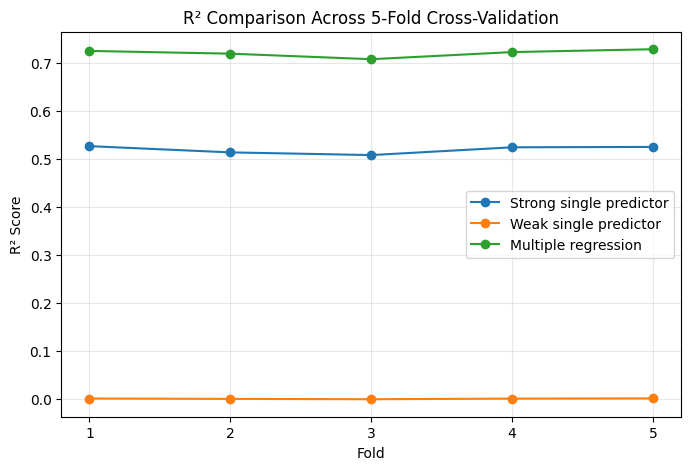

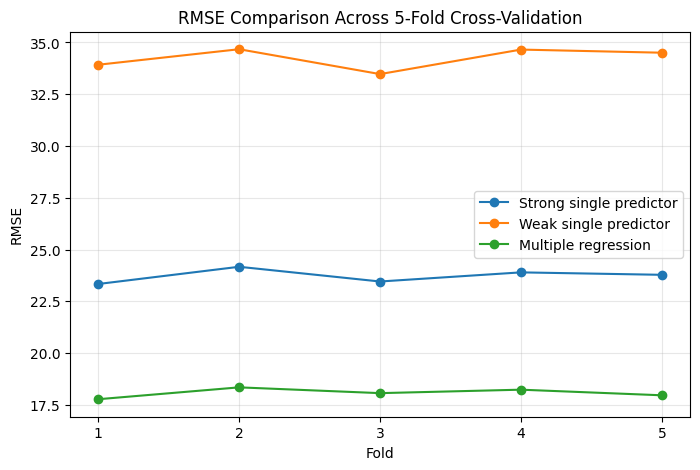

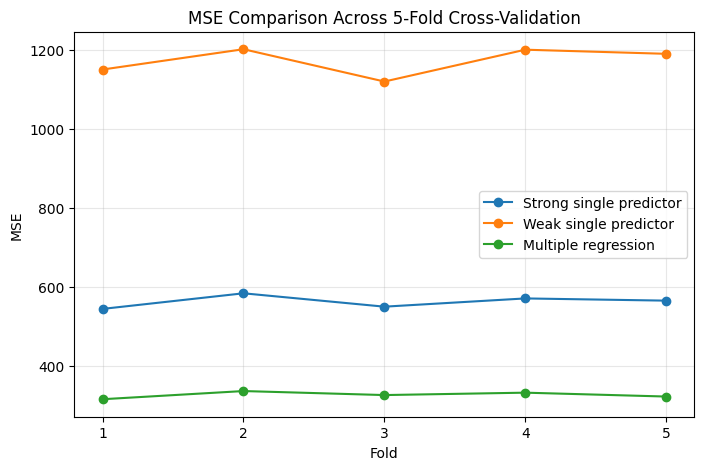

In [58]:
import matplotlib.pyplot as plt
import numpy as np

folds = np.arange(1, 6)

# R² comparison

plt.figure(figsize=(8, 5))

plt.plot(folds, r2_strong_scores, marker='o',
         label='Strong single predictor')
plt.plot(folds, r2_weak_scores, marker='o',
         label='Weak single predictor')
plt.plot(folds, r2_multiple_scores, marker='o',
         label='Multiple regression')

plt.xlabel('Fold')
plt.ylabel('R² Score')
plt.title('R² Comparison Across 5-Fold Cross-Validation')
plt.xticks(folds)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# RMSE comparison

plt.figure(figsize=(8, 5))

plt.plot(folds, rmse_strong_scores, marker='o',
         label='Strong single predictor')
plt.plot(folds, rmse_weak_scores, marker='o',
         label='Weak single predictor')
plt.plot(folds, rmse_multiple_scores, marker='o',
         label='Multiple regression')

plt.xlabel('Fold')
plt.ylabel('RMSE')
plt.title('RMSE Comparison Across 5-Fold Cross-Validation')
plt.xticks(folds)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# MSE comparison

plt.figure(figsize=(8, 5))

plt.plot(folds, mse_strong_scores, marker='o',
         label='Strong single predictor')
plt.plot(folds, mse_weak_scores, marker='o',
         label='Weak single predictor')
plt.plot(folds, mse_multiple_scores, marker='o',
         label='Multiple regression')

plt.xlabel('Fold')
plt.ylabel('MSE')
plt.title('MSE Comparison Across 5-Fold Cross-Validation')
plt.xticks(folds)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

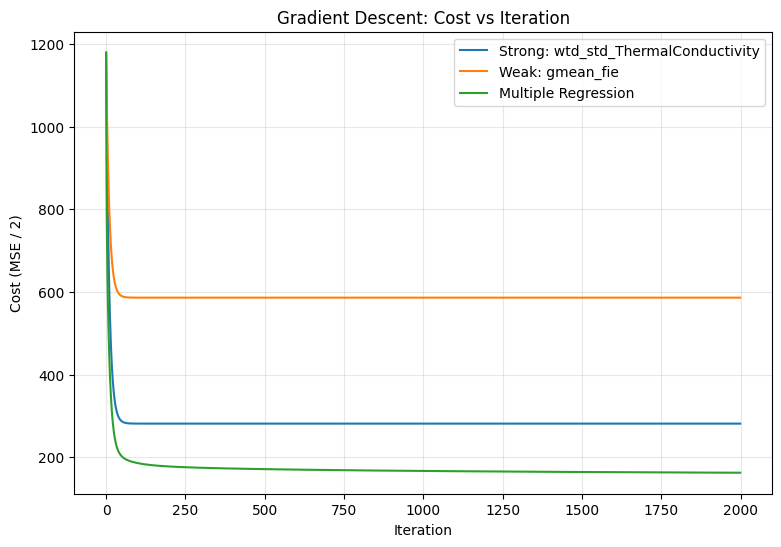

In [60]:
# Cost vs Iteration comparison:
# Strong predictor vs Weak predictor vs Multiple Regression

# --- Strong predictor ---
X_strong = X_full[['wtd_std_ThermalConductivity']].values

scaler_strong_plot = StandardScaler()
X_strong_scaled = scaler_strong_plot.fit_transform(X_strong)

theta_strong, cost_strong = gradient_descent_linear_regression(
    X_strong_scaled,
    y_full,
    learning_rate=learning_rate,
    n_iterations=n_iterations
)


# --- Weak predictor ---
X_weak = X_full[['gmean_fie']].values

scaler_weak_plot = StandardScaler()
X_weak_scaled = scaler_weak_plot.fit_transform(X_weak)

theta_weak, cost_weak = gradient_descent_linear_regression(
    X_weak_scaled,
    y_full,
    learning_rate=learning_rate,
    n_iterations=n_iterations
)


# --- Multiple regression: all predictors ---
X_multiple = X_full.values

scaler_multiple_plot = StandardScaler()
X_multiple_scaled = scaler_multiple_plot.fit_transform(X_multiple)

theta_multiple, cost_multiple = gradient_descent_linear_regression(
    X_multiple_scaled,
    y_full,
    learning_rate=learning_rate,
    n_iterations=n_iterations
)


# --- Plot all three ---
plt.figure(figsize=(9, 6))

plt.plot(cost_strong, label='Strong: wtd_std_ThermalConductivity')
plt.plot(cost_weak, label='Weak: gmean_fie')
plt.plot(cost_multiple, label='Multiple Regression')

plt.xlabel('Iteration')
plt.ylabel('Cost (MSE / 2)')
plt.title('Gradient Descent: Cost vs Iteration')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 2 Exercise-**2**

**Q2.1 **Which features are most suitable/influential in predicting critical_temp? (Tip:consider feature importance ranking, and be careful when interpreting importance in the presence of correlated features.)

In [59]:
# Feature importance from multiple linear regression coefficients

feature_names = X_full.columns

# Exclude intercept (theta[0])
coefficients = theta_multiple[1:].flatten()

# Create DataFrame
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Importance': np.abs(coefficients)
})

# Rank by absolute coefficient
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Display top 15

print("Feature Importance for Predicting 'critical_temp'")
print("(ranked by absolute standardized regression coefficient)\n")

print(feature_importance.head(15))


Feature Importance for Predicting 'critical_temp'
(ranked by absolute standardized regression coefficient)

                          Feature  Coefficient  Importance
62   wtd_mean_ThermalConductivity    15.561797   15.561797
49           std_ElectronAffinity    13.242002   13.242002
47         range_ElectronAffinity   -11.878661   11.878661
27            range_atomic_radius    10.912681   10.912681
7               range_atomic_mass     9.881414    9.881414
22         wtd_mean_atomic_radius     9.483710    9.483710
17                      range_fie     9.382355    9.382355
70    wtd_std_ThermalConductivity     9.126461    9.126461
29              std_atomic_radius    -9.116346    9.116346
44     wtd_gmean_ElectronAffinity    -8.357895    8.357895
64  wtd_gmean_ThermalConductivity    -8.193351    8.193351
80                wtd_std_Valence    -8.055473    8.055473
56         wtd_entropy_FusionHeat     7.485667    7.485667
26      wtd_entropy_atomic_radius     7.069018    7.069018
30     

The standardized regression coefficients are relatively similar in magnitude, with no single attribute clearly dominating the feature-importance ranking. Many of the highly ranked attributes also overlap with other strongly correlated attributes. This multicollinearity makes the individual coefficient rankings difficult to interpret, since correlated predictors may share or redistribute their contribution to the prediction of critical_temp.

wtd_mean_ThermalConductivity has the largest standardized coefficient (15.56), followed by std_ElectronAffinity (13.24), range_ElectronAffinity (−11.88), and range_atomic_radius (10.91). These attributes therefore have the largest coefficient magnitudes in the multiple linear regression model. However, several attributes represent related material properties, and the presence of correlated predictors means the individual coefficient magnitudes and rankings should be interpreted cautiously.

**Q2.2** The models you trained so far assume a linear relationship between features and target.

**a.** Polynomial regression: Using a reduced set of the top 10 features from
Q2.1, extend the feature space to include quadratic and interaction terms.
Does this improve performance? Discuss the risk of overfitting given the increased number of parameters.

Yes performance improves nootably with R2 around .76. Overfitting is a risk.

**b.** Regularization: Train models using Ridge and Lasso regression on all 81
features. Use cross-validation to select the regularization strength α for each.
How do these methods affect the coefficients and model generalization? Which
features does Lasso eliminate, and does this agree with the multicollinear pairs
found in Q1.2.3?

Lasso eliminates what it considers redundant features, but its performance is slightly lower than Ridge in R2 at .70.  Ridge also corrects for large coefficiants by regularizing them, but keeps all the features. It performs better than Lasso in R2 and at .73

**c.** Model comparison: Compare your linear regression results to a non-linear
model (e.g., Decision Tree or Random Forest). Which performs better, and
why?  

The Decision Tree Regression model performed substantially better than the linear regression models, achieving an average R² of 0.8637, an RMSE of 12.64, and an MSE of 159.79 across the five folds. The R² indicates that the Decision Tree explains approximately 86% of the variance in `critical_temp`, compared with approximately 71% for multiple linear regression. This suggests that important relationships between the predictor attributes and critical temperature are nonlinear or involve interactions that are not fully captured by a linear model. The Decision Tree can model these relationships through hierarchical feature splits without explicitly introducing polynomial or interaction terms. However, tree depth and other hyperparameters affect model complexity and should be tuned to control overfitting.
